# Convert flight-arena binary log → MATLAB `.mat`

Utility notebook that turns the raw binary file written by the acquisition software (`logData`) into a `.mat` file matching the variables the MATLAB script saves. The binary is a flat stream of `float64` ("double") values that MATLAB reads with `fread(fid, [9, inf], 'double')`, i.e. a **9 × N**, column-major array. The converter reshapes it accordingly and writes `Data` (optionally also `variables` and `allRandomizedStimOrders`) into a `.mat`.

**Cells:** (1) define the converter, (2) run it on one binary file, (3) plot all 9 channels to sanity-check.

**Inputs:** a binary log file (no extension).  
**Outputs:** a `.mat` file readable by the rest of this pipeline (Step 1 etc.).

---

# 将飞行竞技场二进制日志转换为 MATLAB `.mat`

一个工具型 notebook，用于将采集软件（`logData`）写出的原始二进制文件转换为与 MATLAB 脚本所保存变量相匹配的 `.mat` 文件。该二进制是一串扁平的 `float64`（“double”）数值，MATLAB 用 `fread(fid, [9, inf], 'double')` 读取，即一个**按列优先（column-major）排列的 9 × N** 数组。转换器据此重塑数据，并将 `Data`（可选地还有 `variables` 与 `allRandomizedStimOrders`）写入 `.mat`。

**各单元：**（1）定义转换器；（2）对单个二进制文件运行转换；（3）绘制全部 9 个通道以核查。

**输入：** 一个二进制日志文件（无扩展名）。  
**输出：** 一个可被本流程其余部分（第一步等）读取的 `.mat` 文件。

**Define the converter.** `convert_flightarena_bin_to_mat` reads the whole binary file as `float64`, checks the value count is divisible by `n_rows` (9), reshapes to a 9 × N array with `order='F'` (column-major, to match MATLAB's `fread([9, inf])`), and saves it as `Data` in a `.mat` — a standard v5 file via `scipy.io.savemat`, or true v7.3 (HDF5) via `h5py` if `v7_3=True`.

**定义转换器。** `convert_flightarena_bin_to_mat` 将整个二进制文件按 `float64` 读入，检查数值个数能被 `n_rows`（9）整除，用 `order='F'`（列优先，以匹配 MATLAB 的 `fread([9, inf])`）重塑为 9 × N 数组，并以 `Data` 之名保存到 `.mat`——通过 `scipy.io.savemat` 保存为标准 v5 文件，或在 `v7_3=True` 时通过 `h5py` 保存为真正的 v7.3（HDF5）。

In [9]:
import numpy as np
from pathlib import Path
from scipy.io import savemat, loadmat

def convert_flightarena_bin_to_mat(
    bin_path,
    out_mat_path=None,
    n_rows=9,
    dtype=np.float64,
    variables=None,
    allRandomizedStimOrders=None,
    v7_3=False,
):
    """
    Convert the flight arena binary log file (written by logData) into a .mat
    that matches the MATLAB script's saved variables:
        save(fpath,'Data','variables','allRandomizedStimOrders','-v7.3')

    Assumptions derived from your MATLAB script:
      - Binary contains consecutive float64 ("double") values
      - Data is read in MATLAB via: fread(fid2, [9, inf], 'double')
        => Data is 9 x N and filled column-wise.

    Parameters
    ----------
    bin_path : str|Path
        Path to the binary file with no extension.
    out_mat_path : str|Path|None
        Output .mat path. If None, uses bin_path + '.mat'.
    n_rows : int
        9 in your script.
    dtype : np.dtype
        np.float64 to match MATLAB double.
    variables : object|None
        If you have variables from an existing .mat, pass it here.
    allRandomizedStimOrders : object|None
        If you have it, pass it here.
    v7_3 : bool
        scipy.io.savemat does NOT truly write -v7.3 (HDF5). If you need v7.3,
        set v7_3=True and we will save with h5py instead (see below).

    Returns
    -------
    mdict : dict
        Dict that gets saved (keys include 'Data', optionally 'variables', 'allRandomizedStimOrders').
    """
    bin_path = Path(bin_path)
    if out_mat_path is None:
        out_mat_path = bin_path.with_suffix(".mat")
    else:
        out_mat_path = Path(out_mat_path)

    # --- Read all doubles from file ---
    flat = np.fromfile(bin_path, dtype=dtype)
    if flat.size == 0:
        raise ValueError(f"No data read from {bin_path}. Check file path or permissions.")

    # --- Verify divisible by n_rows ---
    if flat.size % n_rows != 0:
        raise ValueError(
            f"File contains {flat.size} values, not divisible by n_rows={n_rows}.\n"
            "This usually means dtype is wrong (must be float64) or logData wrote a different number of columns."
        )

    n_cols = flat.size // n_rows  # N samples
    # MATLAB fread([9,inf]) fills column-major => reshape with order='F'
    Data = flat.reshape((n_rows, n_cols), order="F")

    mdict = {"Data": Data}
    if variables is not None:
        mdict["variables"] = variables
    if allRandomizedStimOrders is not None:
        mdict["allRandomizedStimOrders"] = allRandomizedStimOrders

    # --- Save .mat ---
    if not v7_3:
        # This creates a standard MAT file (v5). Good for most uses.
        savemat(out_mat_path, mdict, do_compression=True)
    else:
        # True v7.3 requires HDF5. Use h5py.
        import h5py

        with h5py.File(out_mat_path, "w") as f:
            f.create_dataset("Data", data=Data)
            # variables / allRandomizedStimOrders are complicated MATLAB structs/cells;
            # for v7.3, best practice is to store them separately or serialize to JSON.
            if variables is not None:
                raise NotImplementedError(
                    "Saving MATLAB structs/cells as true v7.3 is non-trivial. "
                    "If you need v7.3, tell me what exact fields you need from 'variables' "
                    "and I’ll store them in an HDF5-friendly layout."
                )

    return mdict

**Run the conversion on one file.** Sets the input binary path and the output `.mat` path, then calls the converter and inspects the resulting `Data.shape`.

> ⚠️ **Name mismatch:** this cell calls `bin_to_mat(...)`, but the function defined in the cell above is named `convert_flightarena_bin_to_mat`. `bin_to_mat` is **not defined anywhere in this notebook**, so as written this cell will raise a `NameError` unless `bin_to_mat` happens to exist in the kernel from elsewhere. It looks like a stale / renamed call — intent is to run the converter defined above.

**对单个文件运行转换。** 设置输入二进制路径与输出 `.mat` 路径，然后调用转换器并查看得到的 `Data.shape`。

> ⚠️ **函数名不一致：** 本单元调用的是 `bin_to_mat(...)`，但上一单元定义的函数名为 `convert_flightarena_bin_to_mat`。`bin_to_mat` **在本 notebook 中并未定义**，因此按现状运行本单元会抛出 `NameError`，除非内核中恰好从别处已存在 `bin_to_mat`。这看起来是一个过时／改名后遗留的调用——其本意是运行上面定义的转换器。

In [10]:
bin_file = r'/Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/260114_SpMN4_ChR_EMG/process/SpMN4_ChR_EMG_IS76603_ChR_5d_F_Fly1_Trial1_0ms_thorax_2026_0114_142343'
mat_file = bin_file + "_converted.mat"  # or specify something else

mdict = bin_to_mat(bin_file, mat_file)
Data = mdict["Data"]
Data.shape

Read 323973000 values from /Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/260114_SpMN4_ChR_EMG/process/SpMN4_ChR_EMG_IS76603_ChR_5d_F_Fly1_Trial1_0ms_thorax_2026_0114_142343
Data shape: (9, 35997000) (channels x samples)
Saved MATLAB file: /Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/260114_SpMN4_ChR_EMG/process/SpMN4_ChR_EMG_IS76603_ChR_5d_F_Fly1_Trial1_0ms_thorax_2026_0114_142343_converted.mat


(9, 35997000)

**Sanity-check plot of all 9 channels.** Builds a time axis at `fs = 20000` Hz and plots each of the 9 rows of `Data` in its own panel, with provisional channel labels, so you can confirm the conversion produced sensible signals.

**绘制全部 9 个通道做核查。** 以 `fs = 20000` Hz 构建时间轴，把 `Data` 的 9 行各自画在一个子图中，并附上暂定的通道标签，以便确认转换得到的信号合理。

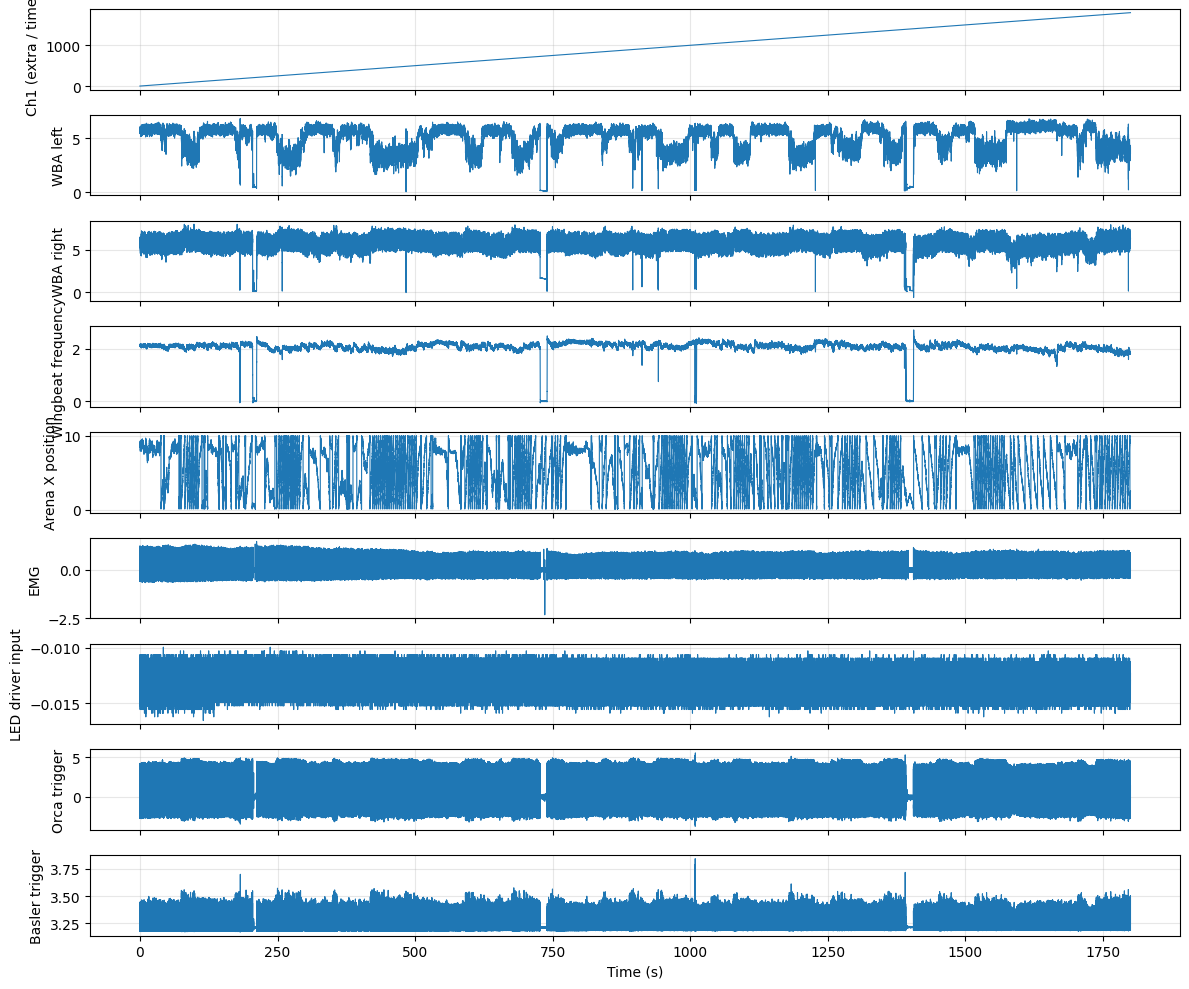

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- inputs ---
fs = 20000
Data = Data  # shape: (9, N)

# --- time axis ---
t = np.arange(Data.shape[1]) / fs

# --- plot ---
fig, axes = plt.subplots(9, 1, figsize=(12, 10), sharex=True)
labels = [
    "Time",
    "WBA Left",
    "WBA Right",
    "Wingbeat Frequency",
    "Arena X position",
    "EMG/Phantom Trigger",
    "LED driver input",
    "Right Hutchen",
    "Basler trigger",
]

for i in range(9):
    axes[i].plot(t, Data[i, :], lw=0.8)
    axes[i].set_ylabel(labels[i])
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()
